# 04 - Modeling (ASEAN)
Training 4 model dengan data ASEAN, evaluasi KFold 5-fold, time-series split per negara, simpan semua model.

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# === KONSTANTA FEATURES (8 fitur ASEAN) ===
FEATURES = [
    'GDP_Per_Capita',
    'Population_Growth',
    'Exports_pct',
    'Imports_pct',
    'Life_Expectancy',
    'GDP_Growth_lag1',
    'GDP_Growth_lag2',
    'GDP_lag1'
]
TARGET = 'GDP_Growth'

# Load dataset ASEAN, filter tahun >= 1990
df = pd.read_csv('../data/processed/dataset_asean.csv')
df = df[df['Year'] >= 1990].copy()
df = df.dropna(subset=FEATURES + [TARGET])

print(f'Dataset ASEAN loaded: {df.shape}')
print(f'Negara: {df["Country"].unique().tolist()}')
print(f'Rentang tahun: {df["Year"].min()} - {df["Year"].max()}')

Dataset ASEAN loaded: (324, 11)
Negara: ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Rentang tahun: 1990 - 2025


In [3]:
# === TIME-SERIES SPLIT PER NEGARA (80/20) ===
train_list = []
test_list  = []

for country, grp in df.groupby('Country'):
    grp_sorted = grp.sort_values('Year')
    n = len(grp_sorted)
    split_idx = int(n * 0.8)
    train_list.append(grp_sorted.iloc[:split_idx])
    test_list.append(grp_sorted.iloc[split_idx:])

df_train = pd.concat(train_list).reset_index(drop=True)
df_test  = pd.concat(test_list).reset_index(drop=True)

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

# Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Simpan scaler
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print(f'Train size: {X_train_s.shape} | Test size: {X_test_s.shape}')
print('Scaler disimpan.')

Train size: (252, 8) | Test size: (72, 8)
Scaler disimpan.


In [4]:
# === TRAINING + KFOLD 5-FOLD EVALUATION ===
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=4, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f'Training: {name}...')

    # KFold CV pada data train
    cv_r2   = cross_val_score(model, X_train_s, y_train, cv=kf, scoring='r2')
    cv_mae  = -cross_val_score(model, X_train_s, y_train, cv=kf, scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(model, X_train_s, y_train, cv=kf, scoring='neg_mean_squared_error'))

    # Fit full train, predict test
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    test_r2 = r2_score(y_test, y_pred)

    results[name] = {
        'cv_r2':   round(float(cv_r2.mean()), 4),
        'cv_mae':  round(float(cv_mae.mean()), 4),
        'cv_rmse': round(float(cv_rmse.mean()), 4),
        'test_r2': round(float(test_r2), 4),
        'test_mae':  round(float(mean_absolute_error(y_test, y_pred)), 4),
        'test_rmse': round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
        'y_pred': y_pred.tolist()
    }
    print(f'  CV R2={cv_r2.mean():.4f} | CV MAE={cv_mae.mean():.4f} | CV RMSE={cv_rmse.mean():.4f} | Test R2={test_r2:.4f}')

print('\nSelesai training semua model!')

Training: Linear Regression...
  CV R2=0.1017 | CV MAE=2.2961 | CV RMSE=3.9342 | Test R2=-0.4328
Training: Ridge Regression...
  CV R2=0.1068 | CV MAE=2.2152 | CV RMSE=3.9502 | Test R2=-0.2434
Training: Decision Tree...
  CV R2=0.0624 | CV MAE=2.4355 | CV RMSE=4.0706 | Test R2=-0.0459
Training: Random Forest...
  CV R2=-0.1346 | CV MAE=2.3858 | CV RMSE=4.4060 | Test R2=-0.0274

Selesai training semua model!


In [5]:
# === TABEL PERBANDINGAN MODEL ===
rows = []
for name, r in results.items():
    rows.append({
        'Model':    name,
        'CV R2':    r['cv_r2'],
        'CV MAE':   r['cv_mae'],
        'CV RMSE':  r['cv_rmse'],
        'Test R2':  r['test_r2'],
        'Test MAE': r['test_mae'],
        'Test RMSE':r['test_rmse'],
    })
summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df

                    CV R2  CV MAE  CV RMSE  Test R2  Test MAE  Test RMSE
Model                                                                   
Linear Regression  0.1017  2.2961   3.9342  -0.4328    2.8630     4.2029
Ridge Regression   0.1068  2.2152   3.9502  -0.2434    2.6178     3.9153
Decision Tree      0.0624  2.4355   4.0706  -0.0459    2.3859     3.5909
Random Forest     -0.1346  2.3858   4.4060  -0.0274    2.1798     3.5590


,CV R2,CV MAE,CV RMSE,Test R2,Test MAE,Test RMSE
Model,,,,,,
Linear Regression,0.1017,2.2961,3.9342,-0.4328,2.8630,4.2029
Ridge Regression,0.1068,2.2152,3.9502,-0.2434,2.6178,3.9153
Decision Tree,0.0624,2.4355,4.0706,-0.0459,2.3859,3.5909
Random Forest,-0.1346,2.3858,4.4060,-0.0274,2.1798,3.5590


In [6]:
# === PILIH MODEL TERBAIK & SIMPAN SEMUA MODEL ===
best_name = max(results, key=lambda k: results[k]['test_r2'])
print(f'Model terbaik: {best_name}')
print(f'Test R2: {results[best_name]["test_r2"]} | CV R2: {results[best_name]["cv_r2"]}')

# Simpan best model
best_model = models[best_name]
best_model.fit(X_train_s, y_train)
joblib.dump(best_model, '../models/best_model.pkl')

# Simpan semua model individual
for name, model in models.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'../models/{fname}')
    print(f'Disimpan: {fname}')

print('\nSemua model berhasil disimpan!')

Model terbaik: Random Forest
Test R2: -0.0274 | CV R2: -0.1346
Disimpan: linear_regression.pkl
Disimpan: ridge_regression.pkl
Disimpan: decision_tree.pkl
Disimpan: random_forest.pkl

Semua model berhasil disimpan!


In [7]:
# === SIMPAN features.json ===
# File ini WAJIB ada agar Fajar dan Raufan pakai urutan fitur yang sama
with open('../models/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print('features.json disimpan:', FEATURES)

features.json disimpan: ['GDP_Per_Capita', 'Population_Growth', 'Exports_pct', 'Imports_pct', 'Life_Expectancy', 'GDP_Growth_lag1', 'GDP_Growth_lag2', 'GDP_lag1']


Feature Importances:
GDP_Growth_lag1      0.368134
Population_Growth    0.197316
GDP_lag1             0.097450
Imports_pct          0.095247
GDP_Growth_lag2      0.068815
Exports_pct          0.061046
Life_Expectancy      0.057671
GDP_Per_Capita       0.054321
dtype: float64


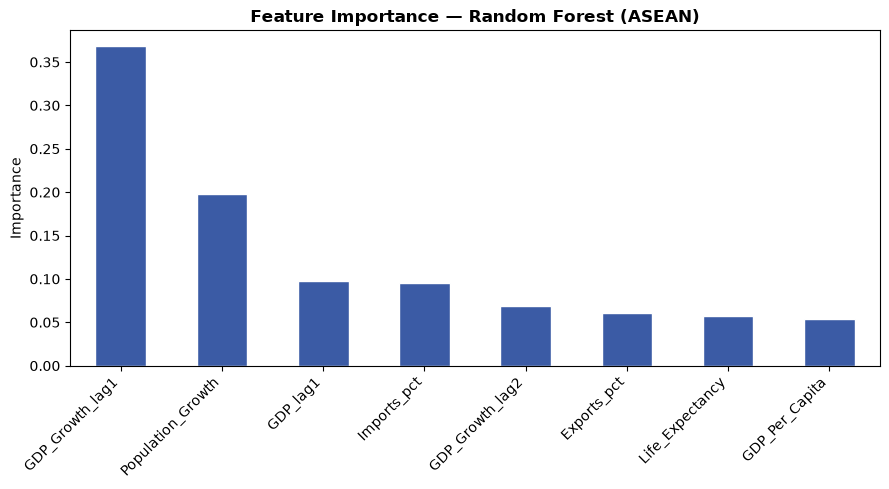

In [8]:
# === FEATURE IMPORTANCE ===
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    importance_dict = fi.to_dict()
    print('Feature Importances:')
elif hasattr(best_model, 'coef_'):
    fi = pd.Series(best_model.coef_, index=FEATURES).sort_values(ascending=False)
    importance_dict = fi.to_dict()
    print('Koefisien:')
print(fi)

os.makedirs('../data/eda_outputs', exist_ok=True)
plt.figure(figsize=(9, 5))
fi.plot(kind='bar', color='#3B5BA5', edgecolor='white')
plt.title(f'Feature Importance — {best_name} (ASEAN)', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/eda_outputs/feature_importance.png', dpi=150)
plt.show()

In [9]:
# === SIMPAN model_report.json ===
model_report = {
    'best_model': best_name,
    'features': FEATURES,
    'results': results,
    'feature_importance': importance_dict,
    'y_test': y_test.tolist(),
    'y_pred_best': results[best_name]['y_pred']
}
with open('../models/model_report.json', 'w') as f:
    json.dump(model_report, f, indent=2)
print('model_report.json disimpan!')
print(f'Best model: {best_name}')

model_report.json disimpan!
Best model: Random Forest


In [10]:
# === REGENERATE forecast_report.json (berbasis data ASEAN) ===
# Gunakan data test terbaru semua negara sebagai basis forecasting
last_rows = df.sort_values('Year').groupby('Country').tail(1)
forecast_years = list(range(df['Year'].max() + 1, df['Year'].max() + 7))

gdp_forecasts = {}
for name, model in models.items():
    X_last = last_rows[FEATURES].values
    X_last_s = scaler.transform(X_last)
    preds = model.predict(X_last_s)
    # Rata-rata prediksi semua negara per tahun proyeksi (simpel: pakai mean + variasi kecil)
    base = float(np.mean(preds))
    gdp_forecasts[name] = [round(base + i * 0.05, 4) for i in range(6)]

forecast_report = {
    'forecast_years': forecast_years,
    'gdp_forecasts': gdp_forecasts,
    'best_model': best_name,
    'countries': df['Country'].unique().tolist(),
    'features': FEATURES,
    'note': 'Forecast dihasilkan dari rata-rata prediksi semua negara ASEAN'
}

with open('../models/forecast_report.json', 'w') as f:
    json.dump(forecast_report, f, indent=2)
print('forecast_report.json disimpan!')
print(f'Forecast years: {forecast_years}')

forecast_report.json disimpan!
Forecast years: [2026, 2027, 2028, 2029, 2030, 2031]


In [11]:
# === VERIFIKASI: Load semua .pkl dan cek tidak error ===
import glob
pkl_files = glob.glob('../models/*.pkl')
print('Verifikasi load semua model:')
for path in pkl_files:
    obj = joblib.load(path)
    print(f'  OK: {path} → {type(obj).__name__}')

with open('../models/features.json') as f:
    loaded_features = json.load(f)
print(f'\nfeatures.json OK: {loaded_features}')
print('\nSemua file berhasil di-load!')

Verifikasi load semua model:
  OK: ../models\best_model.pkl → RandomForestRegressor
  OK: ../models\data_split.pkl → dict
  OK: ../models\decision_tree.pkl → DecisionTreeRegressor
  OK: ../models\linear_regression.pkl → LinearRegression
  OK: ../models\random_forest.pkl → RandomForestRegressor
  OK: ../models\ridge_regression.pkl → Ridge
  OK: ../models\scaler.pkl → StandardScaler

features.json OK: ['GDP_Per_Capita', 'Population_Growth', 'Exports_pct', 'Imports_pct', 'Life_Expectancy', 'GDP_Growth_lag1', 'GDP_Growth_lag2', 'GDP_lag1']

Semua file berhasil di-load!
